# 01 – Explore CARVIS VIS_A Spectral Data (AU Microscopii)

This notebook loads and visualizes the high-resolution spectral observations of AU Microscopii obtained by the CARMENES instrument (visible arm). These are time-series echelle spectra stored in `*-vis_A.fits` files.

I will:
- List and inspect the available observations.
- Explore the HDU structure of the FITS files.
- Plot flux vs. wavelength for individual spectral orders.
- Visualize continuum and uncertainty.

In [2]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ImageNormalize, LogStretch, PercentileInterval

In [ ]:
fits_root = "../../aumicAE"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

print(f"Loaded {len(vis_a_files)} resolved FITS file paths.")

Loaded 95 resolved FITS file paths.


## Inspect HDU Structure

Each file contains multiple HDUs with flux, continuum, uncertainty, and wavelength data for 61 echelle orders.

In [11]:
with fits.open(vis_a_files[0]) as hdul:
    hdul.info()

Filename: ../../aumicAE1/data/AUMic/CARVIS/car-20190714T01h22m54s-sci-gtoc-vis_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     465   ()      
  1  SPEC          1 ImageHDU         8   (4096, 61)   float32   
  2  CONT          1 ImageHDU         8   (4096, 61)   float32   
  3  SIG           1 ImageHDU         8   (4096, 61)   float32   
  4  WAVE          1 ImageHDU         8   (4096, 61)   float64   


## HDU Meaning

| HDU Index | Name  | Shape       | Description                                                                 |
|-----------|-------|-------------|------------------------------------------------------------------------------|
| 0         | PRIMARY | —          | Header only — no data here                                                  |
| 1         | SPEC  | (4096, 61)  | ! Flux: intensity values per pixel and order                               |
| 2         | CONT  | (4096, 61)  | Continuum: estimated baseline light level                                   |
| 3         | SIG   | (4096, 61)  | Uncertainty: standard deviation (1-σ error)                                 |
| 4         | WAVE  | (4096, 61)  | Wavelength: physical wavelength in Ångströms                                |


## Plot Spectrum of different Orders

Let’s plot the flux, continuum, and uncertainty for one spectral order (for order 0, 10, 20, 30, 40, 50, 60) from the first observation.

In [4]:
def plot_spectral_order(file_path, order_index):
    with fits.open(file_path) as hdul:
        flux = hdul['SPEC'].data[order_index, :]
        wave = hdul['WAVE'].data[order_index, :]
        cont = hdul['CONT'].data[order_index, :]
        sig  = hdul['SIG'].data[order_index, :]

    plt.figure(figsize=(10, 5))
    plt.plot(wave, flux, label='Flux', color='orange')
    plt.plot(wave, cont, '--', label='Continuum', color='blue', alpha=0.6)
    plt.fill_between(wave, flux - sig, flux + sig, color='gray', alpha=0.3, label='Uncertainty')
    plt.xlabel('Wavelength [Å]')
    plt.ylabel('Flux')
    plt.title(f"Spectrum of AU Mic – Order {order_index}")
    plt.legend()
    plt.xlim(wave.min(), wave.max())
    plt.tight_layout()

    os.makedirs("../outputs/plots", exist_ok=True)
    plt.savefig(f"../outputs/plots/spectrum_order_{order_index}.png", dpi=150)
    plt.show()

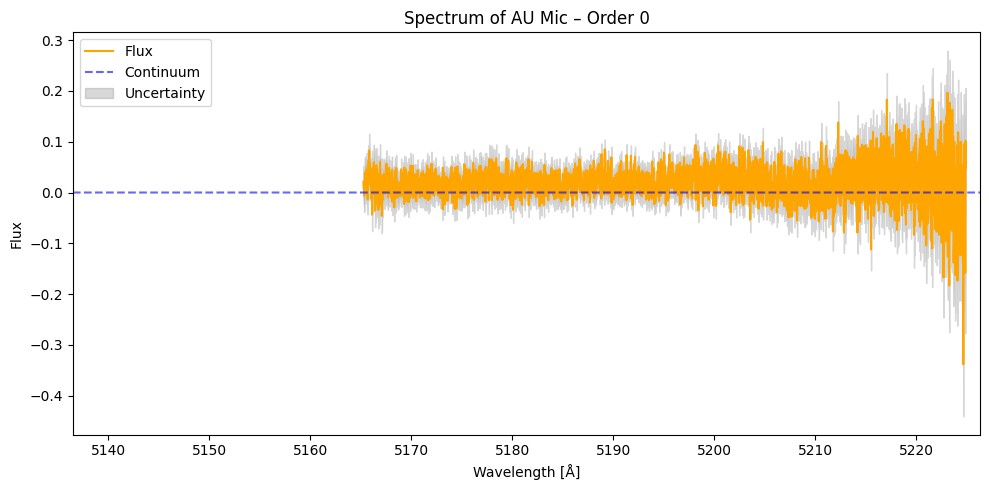

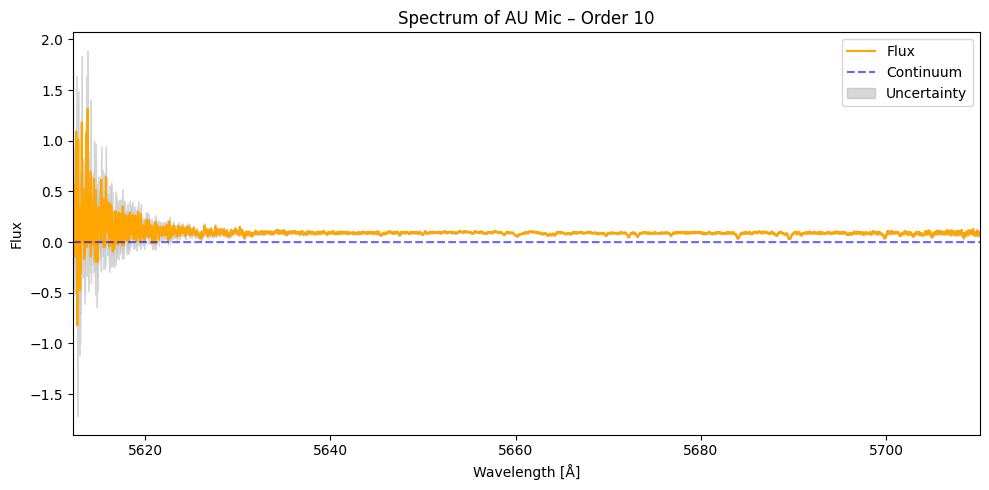

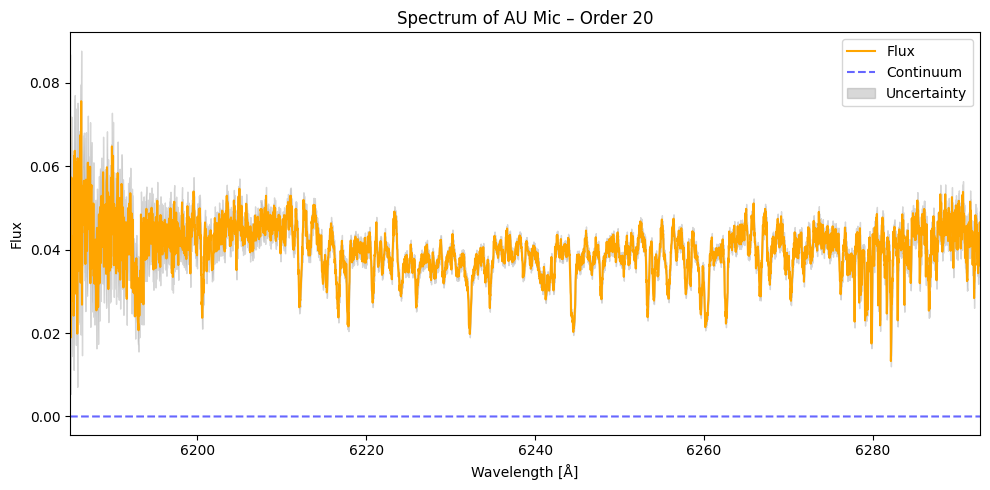

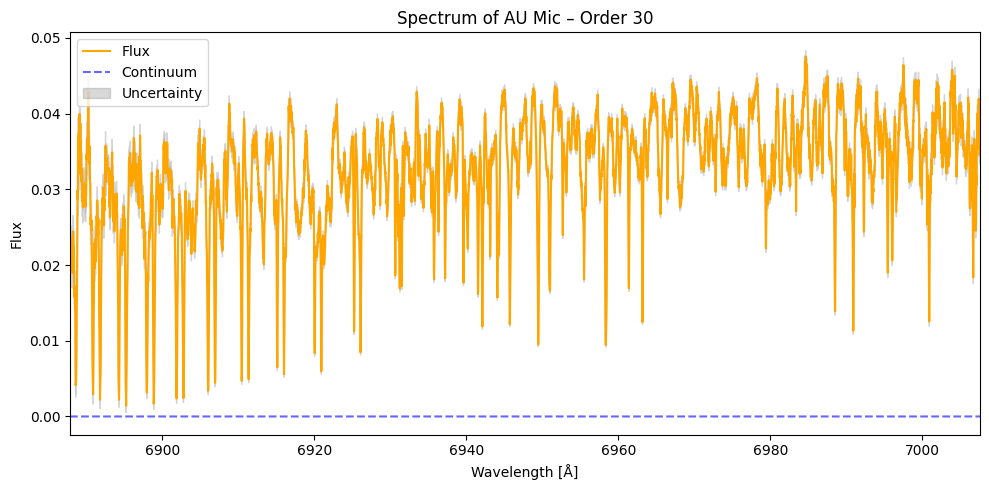

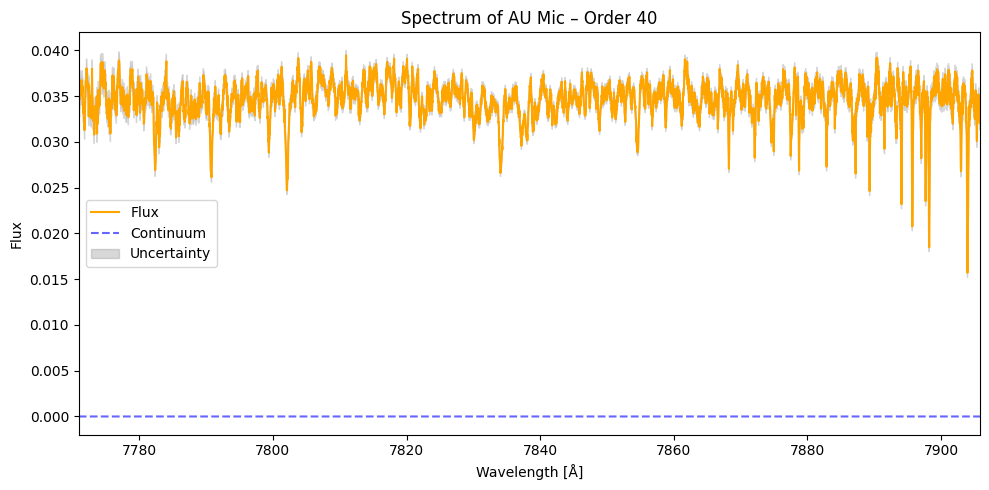

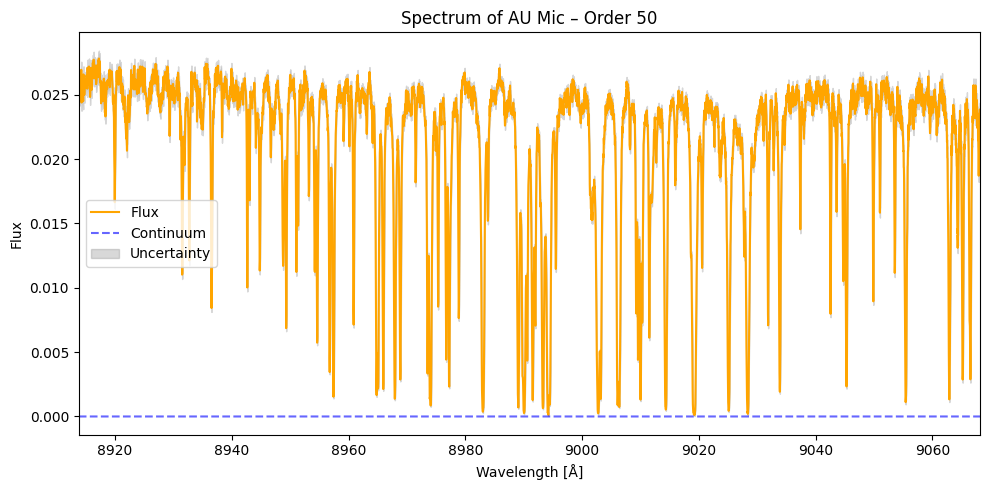

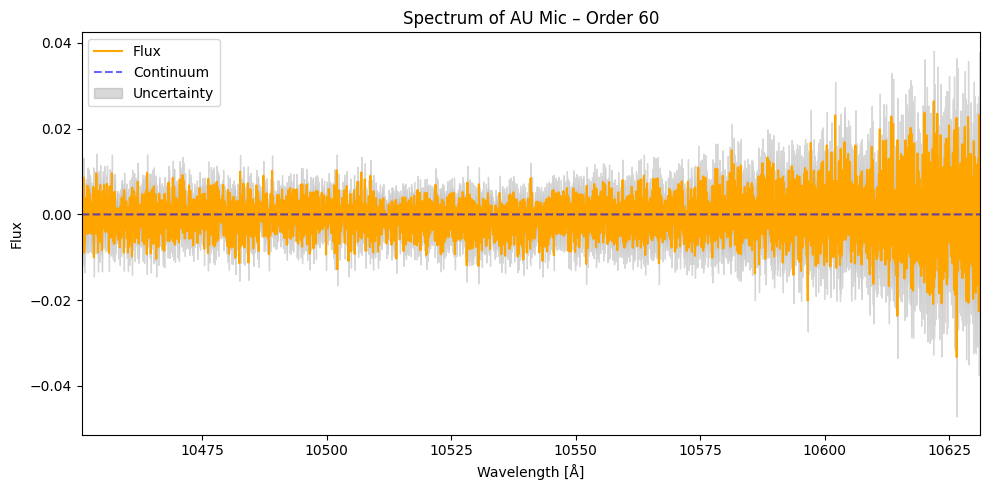

In [5]:
plot_spectral_order(vis_a_files[0], order_index=0)
plot_spectral_order(vis_a_files[0], order_index=10)
plot_spectral_order(vis_a_files[0], order_index=20)
plot_spectral_order(vis_a_files[0], order_index=30)
plot_spectral_order(vis_a_files[0], order_index=40)
plot_spectral_order(vis_a_files[0], order_index=50)
plot_spectral_order(vis_a_files[0], order_index=60)

### Interpretation of AU Mic Spectral Orders (Selected)

| Order | Wavelength Range [Å] | Observations | Interpretation |
|-------|-----------------------|--------------|----------------|
| 0     | ~5140–5225            | Very noisy, wide uncertainty, low and scattered flux | Likely unusable, could be trimmed |
| 10    | ~5610–5715            | Large flux spike around 5615 Å, rapidly decaying flux, high uncertainty | Potential emission line or instrument edge effect |
| 20    | ~6170–6290            | Moderate SNR, structured absorption features | Useful and stable order for analysis |
| 30    | ~6880–7010            | Deep and sharp absorption lines, very low noise | Excellent for line-based diagnostics (e.g., RV shifts) |
| 40    | ~7775–7910            | Smooth continuum, broad and shallow features | Valuable, might contain O I triplet region |
| 50    | ~8915–9065            | Highly structured, sharp features, very high SNR | Scientifically rich — molecular bands? |
| 60    | ~10470–10630          | Low flux, rising noise, wide uncertainty | Likely at detector edge — use with caution |


## Visual Summary

- The spectrum shows intensity vs. wavelength.
- The continuum gives a baseline, useful for normalization.
- The uncertainty highlights noisy regions (typically order edges).


### Key Spectral Orders for Spot Detection

**Order 46 & 47**: These orders contain the Calcium infrared triplet lines, which are highly sensitive to stellar activity and particularly relevant for spot detection. As AU Mic rotates, we expect to observe Doppler shifts in these lines due to the movement of active regions across the stellar disk.

**Order 25:** This order includes the Hydrogen Balmer-alpha line (Hα), associated with the first Balmer transition. It is another crucial indicator of chromospheric activity and helps track rotational modulation of active features.

These specific spectral regions are essential for tracing spot-induced variations in the spectra of AU Mic. Monitoring their line shifts over time allows us to infer surface activity and rotational dynamics.

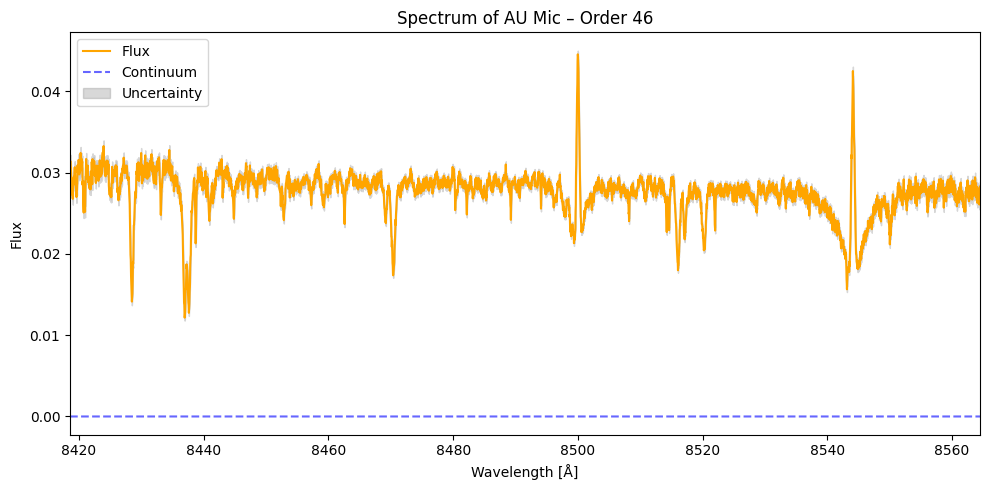

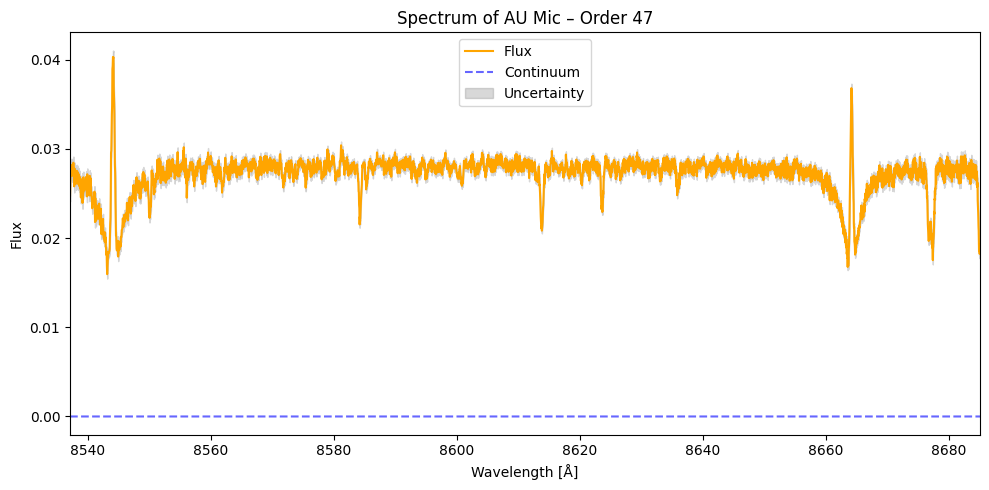

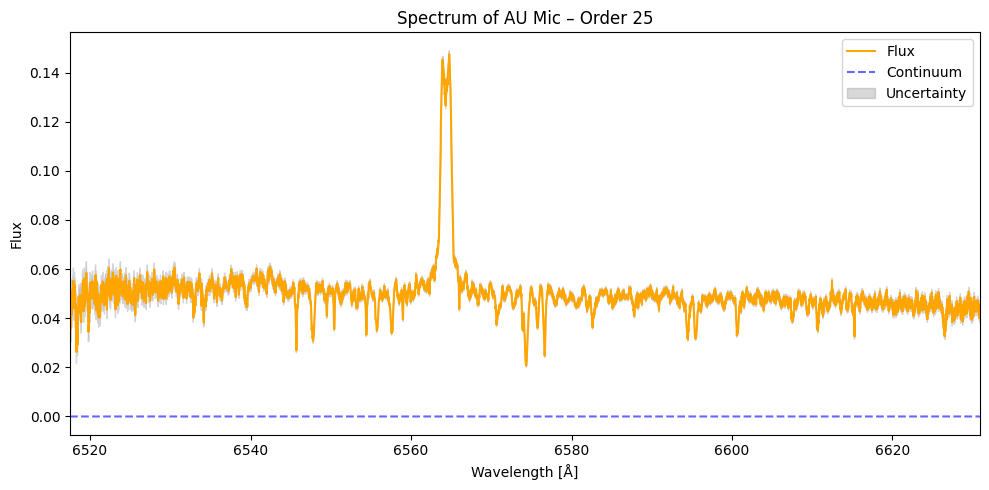

In [6]:
plot_spectral_order(vis_a_files[0], order_index=46)
plot_spectral_order(vis_a_files[0], order_index=47)
plot_spectral_order(vis_a_files[0], order_index=25)

## Inspecting the Header

In [7]:
with fits.open(vis_a_files[0]) as hdul:
    primary_header = hdul[0].header
    print("PRIMARY HDU Header:\n")
    print(repr(primary_header))

    # SPEC extension header:
    spec_header = hdul["SPEC"].header
    print("\nSPEC Header:\n")
    print(repr(spec_header))

PRIMARY HDU Header:

SIMPLE  =                    T /Primary Header created by MWRFITS v1.12         
BITPIX  =                    8 /                                                
NAXIS   =                    0 /                                                
EXTEND  =                    T / FITS dataset may contain extensions            
ECHVERS =              1.00000 / version number of echelle data format          
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT   FITS (Flexible Image Transport System) 2010A&A...524..A42P            
DATAMAX =                 2825 / [adu] Maximum data value in array              
DATAMIN =                 1620 / [adu] Minimum data value in array              
FILENAME= 'car-20190714T01h22m54s-sci-gtoc-vis.fits' / This file name           
OBJECT  = 'J20451-313'         / Observed object                                
DATE-OB

## Removing "noisy" Exposures

I am removing six "bad" exposures, where I can tell it is literally pure noise. I am manually removing them.

## Next Steps

In the next notebook, I will:

- Normalize the spectra (flux / continuum)
- Extract consistent input shapes
- Train autoencoders to learn compressed latent representations
- Track how those representations evolve over time

→ Go to: `02_prototype_autoencoder.ipynb`
